In [25]:
import numpy as np
from pandas import read_csv, DataFrame
from fastccm import PairwiseCCM, utils as fastccm_utils
from time import perf_counter

df = read_csv("../data/Fly80XY_norm_1061.csv")

E = 7
sample = 50
pLibSizes = [10, 20, 80, 90]
tau = 1
Tp = 0
seed = 1

columns = [c for c in df.columns if c != "index"]
libSizes = [int(len(df) * p / 100) for p in pLibSizes]

# Build E-dimensional delay embeddings for each source variable.
embeddings_X = [
    np.array(
        fastccm_utils.embed(df[c].to_numpy()[:, None], E=E, tau=tau)[0],
        copy=True,
        order="C",
    )
    for c in columns
]

embeddings_Y = [
    np.array(df[c].to_numpy()[:, None], copy=True, order="C")
    for c in columns
]

ccm = PairwiseCCM(device="cpu", memory_budget_gb=3)
ccm_matrices = {}

t0 = perf_counter()

for i, libSize in enumerate(libSizes):
    trial_scores = []

    for t in range(sample):
        scores = ccm.score_matrix(
            X_emb=embeddings_X,
            Y_emb=embeddings_Y,
            library_size=libSize,
            sample_size=None,
            exclusion_window=0,
            tp=Tp,
            method="simplex",
            seed=seed + t,
            clean_after=(i == len(libSizes) - 1 and t == sample - 1),
        )
        trial_scores.append(scores[0])

    ccm_matrices[libSize] = DataFrame(
        np.mean(trial_scores, axis=0),
        index=columns,
        columns=columns,
    )

elapsed = perf_counter() - t0

print("libSizes:", libSizes)
print(f"elapsed: {elapsed:.3f}s")

display(ccm_matrices[libSizes[0]].iloc[:5, :5])
display(ccm_matrices[libSizes[-1]].iloc[:5, :5])


libSizes: [106, 212, 848, 954]
elapsed: 13.932s


,TS1,TS2,TS3,TS4,TS5
TS1,0.991040,0.977283,0.966402,0.973147,0.946492
TS2,0.948771,0.988879,0.940028,0.972638,0.933576
TS3,0.956442,0.965049,0.985186,0.967434,0.933672
TS4,0.945648,0.972260,0.944700,0.985625,0.934951
TS5,0.932923,0.951841,0.932042,0.952315,0.982973


,TS1,TS2,TS3,TS4,TS5
TS1,0.998613,0.985353,0.978248,0.982021,0.963515
TS2,0.977530,0.998319,0.962168,0.986982,0.962291
TS3,0.972581,0.972200,0.996985,0.976548,0.958874
TS4,0.972127,0.983848,0.963527,0.997256,0.962877
TS5,0.954839,0.971543,0.958051,0.970404,0.997641


,LibSize,FastCCM,pyEDM
0,106,0.696592,0.696836
1,212,0.708514,0.706984
2,848,0.732947,0.731861
3,954,0.735000,0.734657
4,1061,0.737051,0.737050


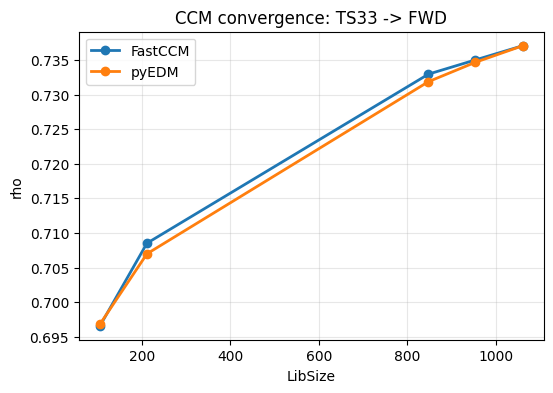

In [26]:
import numpy as np
from pandas import read_csv, DataFrame
from matplotlib import pyplot as plt
from fastccm import PairwiseCCM, utils as fastccm_utils
from pyEDM import CCM

df = read_csv("../data/Fly80XY_norm_1061.csv")

# Pick any pair you want to compare.
source = "TS33"
target = "FWD"

E = 7
sample = 50
pLibSizes = [10, 20, 80, 90, 100]
tau = 1
Tp = 0
seed = 3

libSizes = [int(len(df) * p / 100) for p in pLibSizes]

# FastCCM: embed the source manifold, keep the target scalar.
X_emb = [
    np.array(
        fastccm_utils.embed(df[source].to_numpy()[:, None], E=E, tau=tau)[0],
        copy=True,
        order="C",
    )
]
Y_emb = [
    np.array(df[target].to_numpy()[:, None], copy=True, order="C")
]

ccm = PairwiseCCM(device="cpu", memory_budget_gb=3)
fast_rho = []
for i, libSize in enumerate(libSizes):
    vals = []
    for t in range(sample):
        scores = ccm.score_matrix(
            X_emb=X_emb,
            Y_emb=Y_emb,
            library_size=libSize,
            sample_size=None,
            exclusion_window=0,
            tp=Tp,
            method="simplex",
            seed=seed + t,
            clean_after=(i == len(libSizes) - 1 and t == sample - 1),
        )
        vals.append(scores[0, 0, 0])
    fast_rho.append(np.mean(vals))


# pyEDM CCM on the same pair and same parameters.
pyedm_df = CCM(
    dataFrame=df,
    columns=source,
    target=target,
    libSizes=libSizes,
    sample=sample,
    E=E,
    Tp=Tp,
    tau=-tau,         
    exclusionRadius=0,
    seed=seed,
    noTime=False,
)

pyedm_rho = pyedm_df[f"{source}:{target}"].to_numpy()

compare_df = DataFrame(
    {
        "LibSize": libSizes,
        "FastCCM": fast_rho,
        "pyEDM": pyedm_rho,
    }
)

display(compare_df)

ax = compare_df.plot(
    x="LibSize",
    y=["FastCCM", "pyEDM"],
    marker="o",
    linewidth=2,
    figsize=(6, 4),
    title=f"CCM convergence: {source} -> {target}",
)
ax.set_ylabel("rho")
ax.grid(True, alpha=0.3)
plt.show()


## Fly slope matrices at fixed E=7

This mirrors the MDE `ccmSlope` rule: normalize library sizes to `[0, 1]`, fit a line to `rho(L)`, and use that slope as the convergence score. The code below computes the full `FastCCM` slope matrix for the Fly data and a second matrix masked by `slope > 0.05`.

,TS1,TS2,TS3,TS4,TS5,TS6,TS7,TS8,TS9,TS10,...,TS73,TS74,TS75,TS76,TS77,TS78,TS79,TS80,Left_Right,FWD
TS1,0.0072,0.0277,0.0158,0.0255,0.0209,0.0258,0.0087,0.0159,0.0339,0.0230,...,0.1321,0.0272,0.1687,0.1805,0.1481,0.1000,0.1686,0.1555,0.0984,0.0942
TS2,0.0085,0.0088,0.0074,0.0113,0.0196,0.0114,0.0158,0.0135,0.0175,0.0499,...,0.1127,0.0227,0.1711,0.1572,0.1472,0.1181,0.2225,0.1317,0.1170,0.0678
TS3,0.0121,0.0216,0.0114,0.0184,0.0254,0.0162,0.0159,0.0124,0.0334,0.0475,...,0.1229,0.0455,0.1613,0.1712,0.1575,0.1091,0.2492,0.2042,0.1505,0.1057
TS4,0.0096,0.0140,0.0092,0.0113,0.0179,0.0115,0.0162,0.0091,0.0232,0.0486,...,0.1309,0.0736,0.1319,0.2058,0.1642,0.1597,0.2429,0.1722,0.2738,0.0834
TS5,0.0176,0.0280,0.0257,0.0273,0.0137,0.0312,0.0238,0.0152,0.0380,0.0440,...,0.1230,0.0485,0.2344,0.2121,0.1930,0.1301,0.1681,0.2439,0.2179,0.0937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TS78,0.0324,0.0469,0.0338,0.0380,0.0442,0.0246,0.0200,0.0125,0.0378,0.0247,...,0.0243,0.0219,0.0416,0.0614,0.0271,0.0321,0.1051,0.0309,0.1265,0.0924
TS79,0.0434,0.0309,0.0291,0.0241,0.0177,0.0186,0.0237,0.0302,0.0383,0.0662,...,0.0215,0.0837,0.0866,0.0782,0.0536,0.0629,0.0274,0.0681,0.0336,0.0649
TS80,0.0591,0.0781,0.0467,0.0767,0.0494,0.0738,0.0595,0.0563,0.0419,0.0665,...,0.0122,0.0771,0.1008,0.0433,0.0969,0.0409,-0.0041,0.0211,0.0977,0.0781
Left_Right,0.0730,0.0700,0.0771,0.0620,0.0558,0.0601,0.0658,0.0548,0.0635,0.0616,...,0.1162,0.0527,0.0800,0.1698,0.1033,0.1534,0.0266,0.0684,0.0578,0.0422


,TS1,TS2,TS3,TS4,TS5,TS6,TS7,TS8,TS9,TS10,...,TS73,TS74,TS75,TS76,TS77,TS78,TS79,TS80,Left_Right,FWD
TS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.7234,NaN,0.4385,0.4710,0.5043,0.7421,0.3558,0.4886,0.4033,0.9161
TS2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.7051,NaN,0.4845,0.5152,0.5446,0.6615,0.4888,0.4092,0.4613,0.9139
TS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.7236,NaN,0.5299,0.4630,0.4493,0.7048,0.4363,0.5658,0.3464,0.8709
TS4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.7104,0.7365,0.4475,0.5165,0.5004,0.6978,0.4892,0.4859,0.5853,0.9152
TS5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.6540,NaN,0.5153,0.5247,0.5220,0.6991,0.3438,0.5827,0.5591,0.9231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TS78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.4193,NaN,NaN,0.2328,NaN,0.2677,0.3529
TS79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3538,...,NaN,0.2009,0.1687,0.2462,0.1629,0.2198,NaN,0.2712,NaN,0.2275
TS80,0.1300,0.1419,NaN,0.1391,NaN,0.1560,0.1641,0.1156,NaN,0.1809,...,NaN,0.2232,0.1354,NaN,0.2062,NaN,NaN,NaN,0.1493,0.1769
Left_Right,0.7578,0.7871,0.7763,0.7886,0.7909,0.7765,0.7252,0.7463,0.8034,0.5807,...,0.4246,0.4647,0.2398,0.3826,0.2597,0.3758,NaN,0.1683,0.9806,NaN


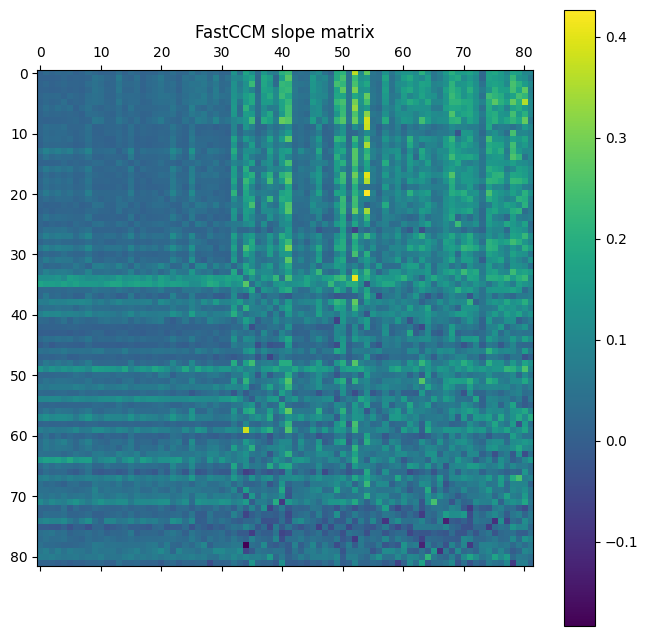

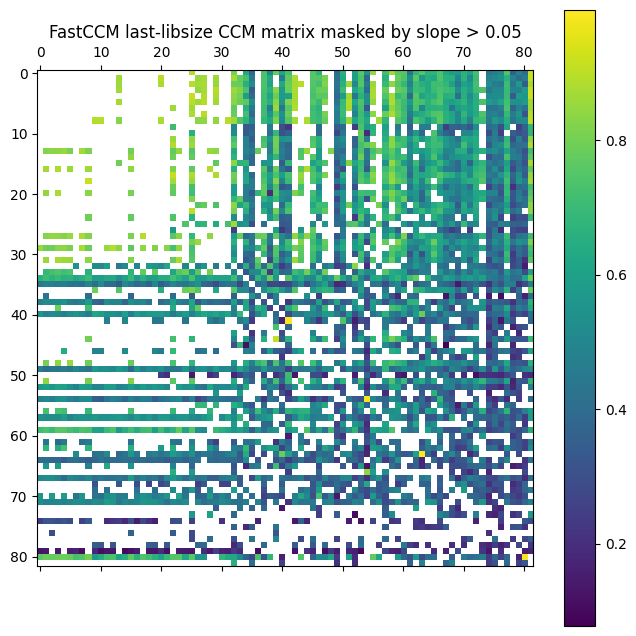

In [29]:
import numpy as np
from pandas import read_csv, DataFrame
from matplotlib import pyplot as plt
from fastccm import PairwiseCCM, utils as fastccm_utils

# Re-load the Fly data so this section can run independently.
df = read_csv("../data/Fly80XY_norm_1061.csv")

def slope_matrix_from_curves(lib_sizes, matrices_by_lib_size):
    x = np.asarray(lib_sizes, dtype=float)
    x = x / x[-1]
    x_centered = x - x.mean()
    denom = np.sum(x_centered ** 2)

    matrix_stack = np.stack(
        [matrices_by_lib_size[lib_size].to_numpy(dtype=float) for lib_size in lib_sizes],
        axis=0,
    )
    matrix_stack = np.nan_to_num(matrix_stack, nan=0.0)
    y_centered = matrix_stack - matrix_stack.mean(axis=0, keepdims=True)

    return np.tensordot(x_centered, y_centered, axes=(0, 0)) / denom


E_fixed = 7
sample = 50
pLibSizes = [10, 20, 80, 90]
tau = 1
Tp = 0
seed = 3
slope_threshold = 0.05

columns = [column for column in df.columns if column != "index"]
libSizes = [int(len(df) * p / 100) for p in pLibSizes]
tau_abs = abs(tau)

# Embed every source once, then score all source/target pairs at each library size.
embeddings_X = [
    np.array(
        fastccm_utils.embed(df[column].to_numpy()[:, None], E=E_fixed, tau=tau_abs)[0],
        copy=True,
        order="C",
    )
    for column in columns
]
embeddings_Y = [
    np.array(df[column].to_numpy()[:, None], copy=True, order="C")
    for column in columns
]

ccm = PairwiseCCM(device="cpu", memory_budget_gb=3)
rho_matrices = {}

for i, lib_size in enumerate(libSizes):
    trial_scores = []
    for trial in range(sample):
        scores = ccm.score_matrix(
            X_emb=embeddings_X,
            Y_emb=embeddings_Y,
            library_size=lib_size,
            sample_size=None,
            exclusion_window=0,
            tp=Tp,
            method="simplex",
            seed=seed + trial,
            clean_after=(i == len(libSizes) - 1 and trial == sample - 1),
        )
        trial_scores.append(scores[0])

    rho_matrices[lib_size] = DataFrame(
        np.mean(trial_scores, axis=0),
        index=columns,
        columns=columns,
    )

slope_matrix = DataFrame(
    slope_matrix_from_curves(libSizes, rho_matrices),
    index=columns,
    columns=columns,
).T
last_libsize_matrix = rho_matrices[libSizes[-1]].T
masked_last_libsize_matrix = last_libsize_matrix.where(slope_matrix > slope_threshold)

display(slope_matrix.round(4))
display(masked_last_libsize_matrix.round(4))

plt.figure(figsize=(8, 8))
plt.matshow(slope_matrix, fignum=False)
plt.title("FastCCM slope matrix")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.matshow(masked_last_libsize_matrix, fignum=False)
plt.title(f"FastCCM last-libsize CCM matrix masked by slope > {slope_threshold}")
plt.colorbar()
plt.show()
